# Recitation: Unsupervised Learning 2
### Topics: PCA and DBSCAN

In this recitation, we will explore two more unsupervised learning techniques:
- **PCA (Principal Component Analysis)**: for reducing dimensions and visualizing high-dimensional data
- **DBSCAN**: a density-based clustering algorithm that can find clusters of arbitrary shape and detect noise

---

## Quick Recap: Unsupervised Learning

In unsupervised learning, we are given data **without labels**.
The goal is to uncover **patterns, structure, or relationships** within the data.

---

## Supervised vs Unsupervised Learning

| Supervised Learning         | Unsupervised Learning         |
|----------------------------|-------------------------------|
| Has labeled data            | No labels                     |
| Predict specific target     | Find patterns or structure     |
| Examples: regression, classification | Examples: clustering, dimensionality reduction |

---

## Real-World Applications

- **Customer segmentation**: group customers by behavior
- **Anomaly detection**: identify outliers in network traffic or manufacturing
- **Topic modeling**: group articles/documents by topic
- **Data compression**: reduce dimensionality for visualization or storage

---

We'll start by loading the dataset and preparing it for PCA and clustering.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

# Load dataset
data = load_iris()
X = data.data
y = data.target
feature_names = data.feature_names
target_names = data.target_names

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [2]:
X.shape

(150, 4)

For the original-feature visualizations in this recitation, we'll use two of the original features:
**petal length** and **petal width** (indices 2 and 3). These two features alone separate the
Iris classes well, so they are convenient for plotting in 2D.

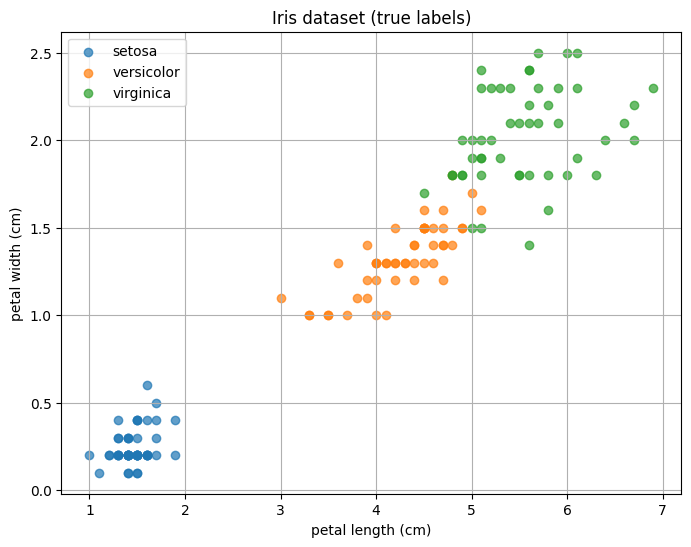

In [3]:
# Pick two features for 2D visualization
f1, f2 = 2, 3  # petal length, petal width
xlabel, ylabel = feature_names[f1], feature_names[f2]

plt.figure(figsize=(8, 6))
for i, target in enumerate(np.unique(y)):
    plt.scatter(X[y == target, f1], X[y == target, f2], label=target_names[i], alpha=0.7)
plt.xlabel(xlabel)
plt.ylabel(ylabel)
plt.title("Iris dataset (true labels)")
plt.legend()
plt.grid(True)
plt.show()

## Section 2: Principal Component Analysis (PCA)

**PCA** is a technique for **dimensionality reduction**.

It projects high-dimensional data into a lower-dimensional space while:
- Preserving as much **variance** in the data as possible
- Creating **uncorrelated** features called *principal components*

PCA is widely used for:
- **Visualizing high-dimensional datasets**
- **Reducing noise**
- **Speeding up algorithms by lowering feature count**

---

### Key Concepts

- **Principal components**: new axes that capture the directions of highest variance
- **Explained variance ratio**: how much of the total variance each component captures

---

### How to Choose the Number of Components?

A common approach is to plot the **cumulative explained variance** and pick enough components to capture **90-95%** of the variance.

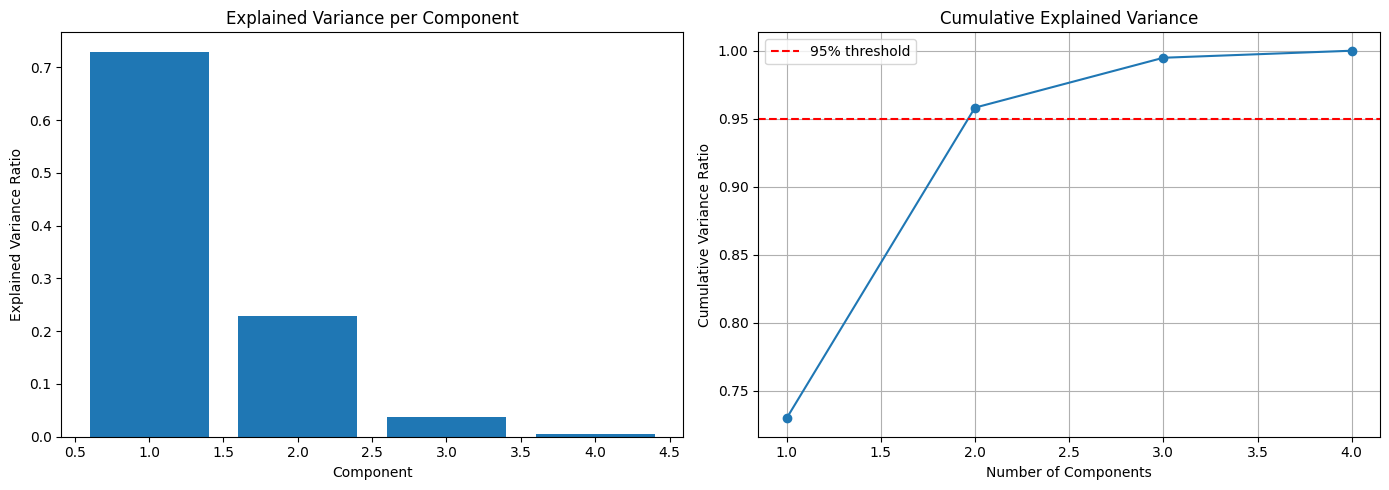

In [4]:
from sklearn.decomposition import PCA

# Fit PCA on all components
pca = PCA()
X_pca_full = pca.fit_transform(X_scaled)

# Plot explained variance
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1),
        pca.explained_variance_ratio_)
plt.title("Explained Variance per Component")
plt.xlabel("Component")
plt.ylabel("Explained Variance Ratio")

plt.subplot(1, 2, 2)
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
         np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.axhline(0.95, color='red', linestyle='--', label='95% threshold')
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance Ratio")
plt.legend()

plt.tight_layout()
plt.grid(True)
plt.show()

Choose the number of components where the cumulative variance curve crosses your target threshold (often **90-95%**).

Let's reduce the data to 2D and visualize it in the principal-component space.

Explained variance by PC1, PC2: [0.72962445 0.22850762]
Total: 0.9581320720000166


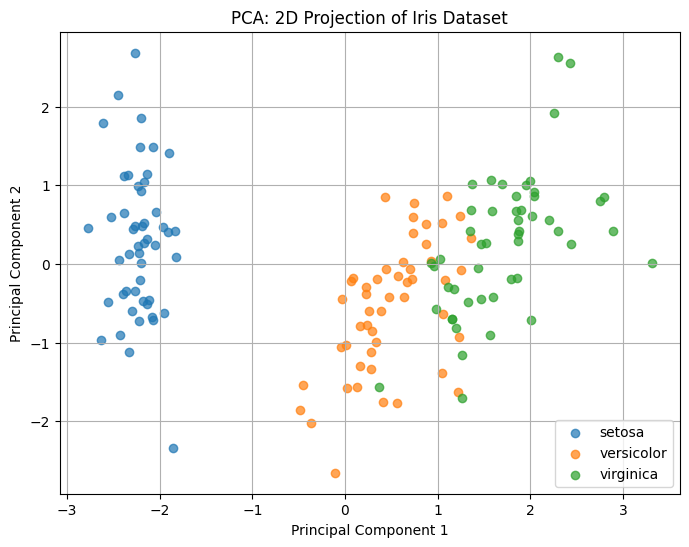

In [5]:
# Reduce to 2 dimensions
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

print("Explained variance by PC1, PC2:", pca_2d.explained_variance_ratio_)
print("Total:", pca_2d.explained_variance_ratio_.sum())

# Plot in 2D
plt.figure(figsize=(8, 6))
for i, target in enumerate(np.unique(y)):
    plt.scatter(X_2d[y == target, 0], X_2d[y == target, 1],
                label=target_names[i], alpha=0.7)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA: 2D Projection of Iris Dataset")
plt.legend()
plt.grid(True)
plt.show()

We've reduced a 4D dataset into 2 dimensions while keeping most of the variance, making it easier to visualize.

In the next section, we'll apply **DBSCAN** clustering and use the PCA projection to help visualize the cluster assignments.

## Section 3: DBSCAN Clustering

**DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) groups together points that are **densely packed**, and marks points that lie alone in low-density regions as **noise**.

Unlike K-Means, DBSCAN:
- Does **not** require us to specify the number of clusters in advance
- Can find **arbitrarily shaped** clusters (not only spherical)
- Can identify **outliers/noise points** explicitly (label `-1`)

---

### Key Parameters

- `eps`: the maximum distance between two points for them to be considered neighbors
- `min_samples`: the minimum number of points required to form a dense region (a *core point*)

### Point types
- **Core point**: has at least `min_samples` neighbors within distance `eps`
- **Border point**: within `eps` of a core point, but has fewer than `min_samples` neighbors itself
- **Noise point**: neither core nor border

---

### How to Choose `eps`?

A common heuristic is the **k-distance plot**: for each point, compute the distance to its `k`-th nearest neighbor (where `k = min_samples`), sort these distances, and look for a *knee* (sharp bend). The distance at the knee is a good candidate for `eps`.

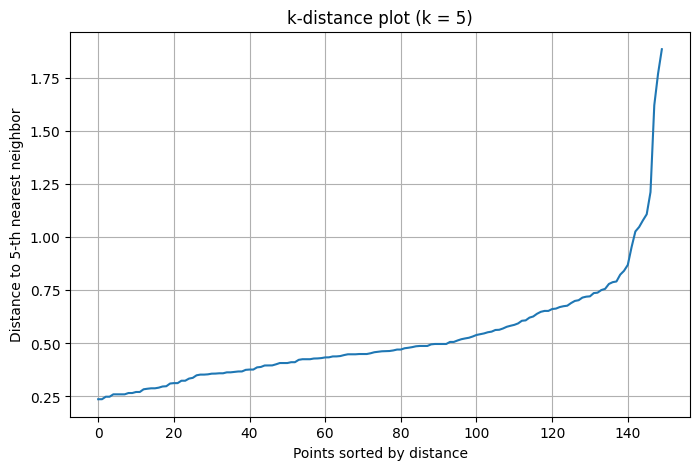

In [6]:
from sklearn.neighbors import NearestNeighbors

# Use min_samples roughly equal to 2 * num_features as a starting guideline
min_samples = 5

nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)

# Distance to the k-th nearest neighbor, sorted
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.title(f"k-distance plot (k = {min_samples})")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"Distance to {min_samples}-th nearest neighbor")
plt.grid(True)
plt.show()

Pick `eps` near the **knee** of the curve — the point where the distance starts increasing sharply. For standardized Iris with `min_samples=5`, a value around `eps ≈ 0.8` works well.

Let's fit DBSCAN and visualize the clusters in the PCA 2D space.

In [7]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

eps = 0.8
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
db_labels = dbscan.fit_predict(X_scaled)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = int(np.sum(db_labels == -1))
print(f"Number of clusters found: {n_clusters}")
print(f"Number of noise points:   {n_noise}")

# Silhouette score is only meaningful when we have >= 2 clusters
# and we should ignore the noise points when computing it
mask = db_labels != -1
if len(set(db_labels[mask])) > 1:
    sil = silhouette_score(X_scaled[mask], db_labels[mask])
    print(f"Silhouette (excluding noise): {sil:.3f}")

Number of clusters found: 2
Number of noise points:   4
Silhouette (excluding noise): 0.598


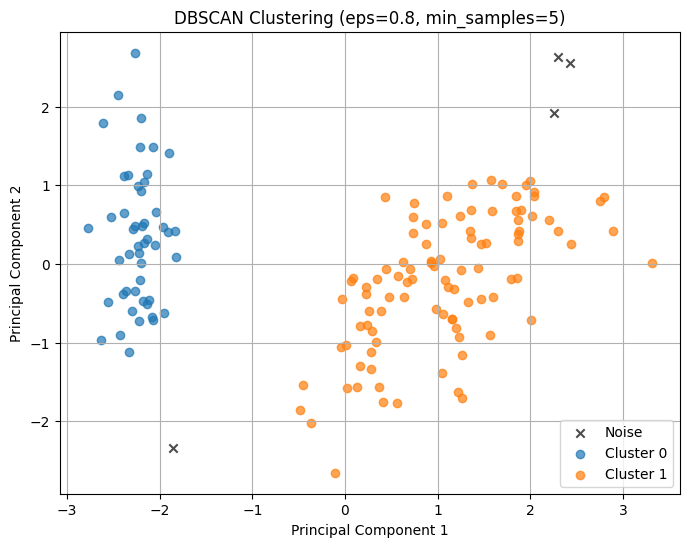

In [8]:
# Visualize DBSCAN result in PCA 2D space
plt.figure(figsize=(8, 6))
unique_labels = sorted(set(db_labels))
for label in unique_labels:
    if label == -1:
        # Noise points
        plt.scatter(X_2d[db_labels == label, 0],
                    X_2d[db_labels == label, 1],
                    label="Noise", c='black', marker='x', alpha=0.7)
    else:
        plt.scatter(X_2d[db_labels == label, 0],
                    X_2d[db_labels == label, 1],
                    label=f"Cluster {label}", alpha=0.7)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title(f"DBSCAN Clustering (eps={eps}, min_samples={min_samples})")
plt.legend()
plt.grid(True)
plt.show()

Let's also look at the same DBSCAN labels in the original feature space (petal length vs. petal width).

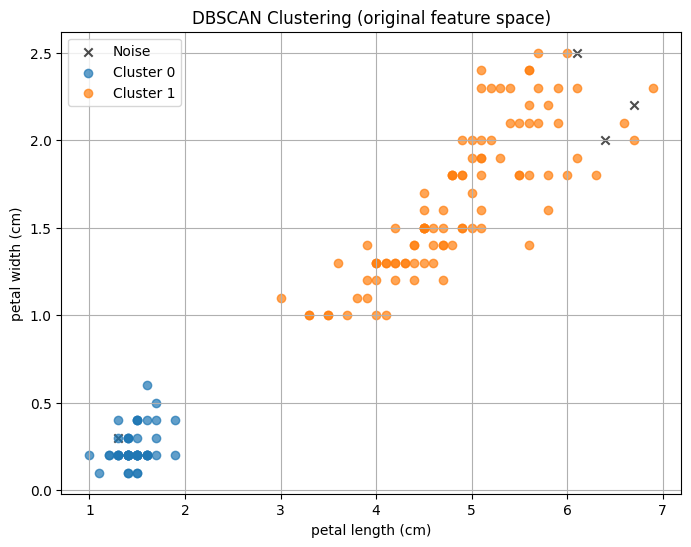

In [9]:
plt.figure(figsize=(8, 6))
for label in unique_labels:
    if label == -1:
        plt.scatter(X[db_labels == label, f1], X[db_labels == label, f2],
                    label="Noise", c='black', marker='x', alpha=0.7)
    else:
        plt.scatter(X[db_labels == label, f1], X[db_labels == label, f2],
                    label=f"Cluster {label}", alpha=0.7)

plt.xlabel(xlabel)
plt.ylabel(ylabel)
plt.title("DBSCAN Clustering (original feature space)")
plt.legend()
plt.grid(True)
plt.show()

### Effect of `eps`

DBSCAN is very sensitive to `eps`. Let's see how the result changes for different values.

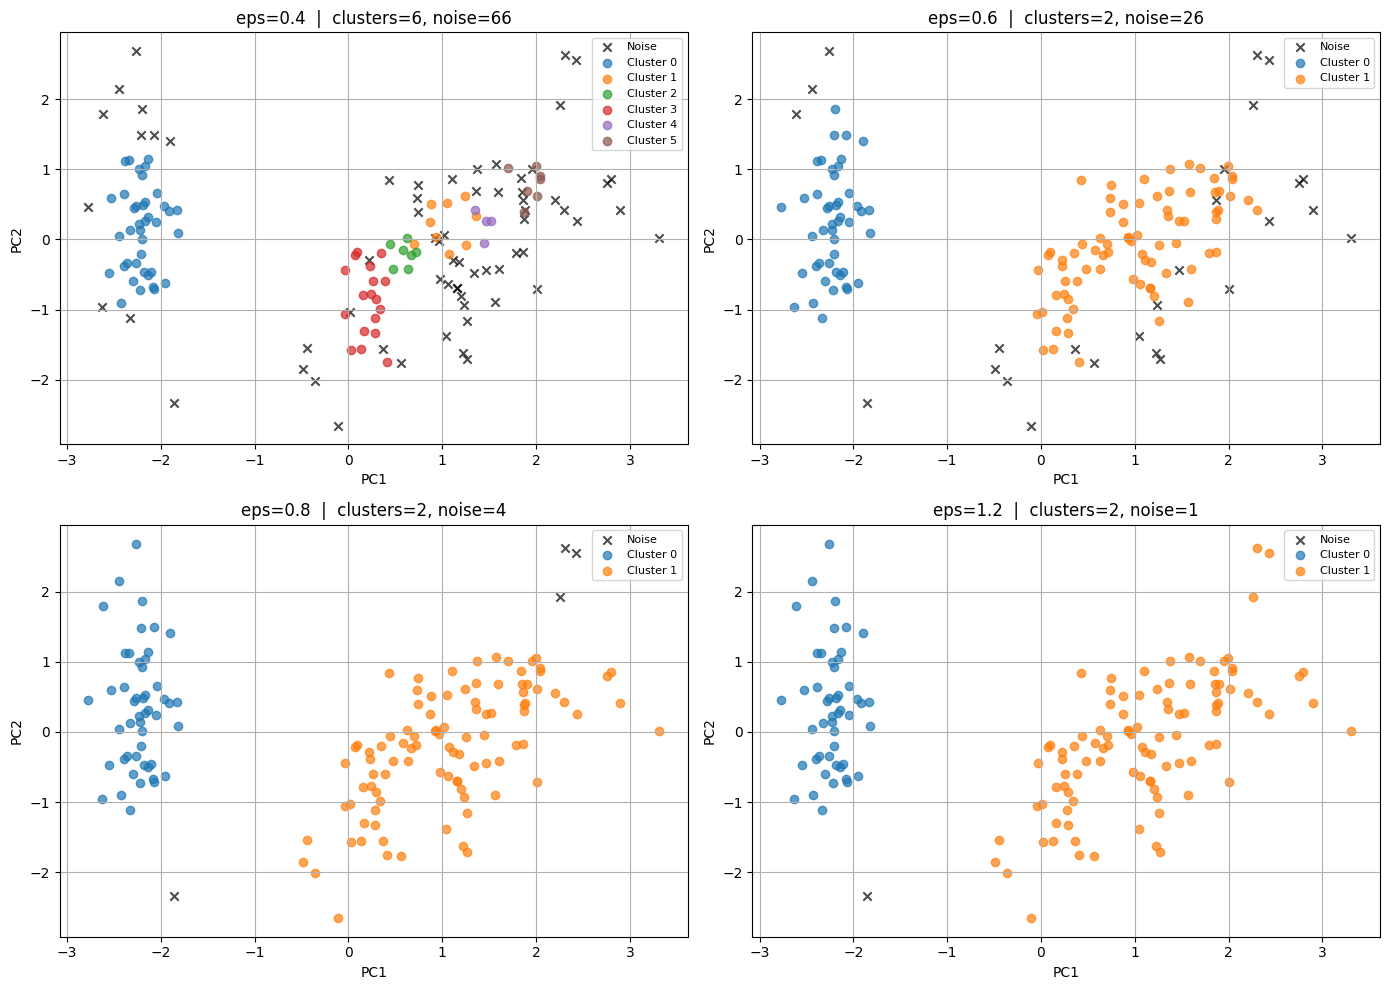

In [10]:
eps_values = [0.4, 0.6, 0.8, 1.2]

plt.figure(figsize=(14, 10))
for idx, e in enumerate(eps_values, 1):
    labels_e = DBSCAN(eps=e, min_samples=min_samples).fit_predict(X_scaled)
    n_c = len(set(labels_e)) - (1 if -1 in labels_e else 0)
    n_n = int(np.sum(labels_e == -1))

    plt.subplot(2, 2, idx)
    for label in sorted(set(labels_e)):
        if label == -1:
            plt.scatter(X_2d[labels_e == label, 0], X_2d[labels_e == label, 1],
                        c='black', marker='x', alpha=0.7, label='Noise')
        else:
            plt.scatter(X_2d[labels_e == label, 0], X_2d[labels_e == label, 1],
                        alpha=0.7, label=f'Cluster {label}')
    plt.title(f"eps={e}  |  clusters={n_c}, noise={n_n}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend(fontsize=8)
    plt.grid(True)

plt.tight_layout()
plt.show()

Notice how:
- **Small `eps`**: many points labeled as noise, clusters fragment.
- **Large `eps`**: distinct clusters merge into one big cluster.
- The **right `eps`** separates the dense regions cleanly while keeping noise reasonable.

## Section 4: Wrap-Up Summary

In this recitation, we covered two unsupervised learning techniques that complement what we saw last week:

---

### Comparison of Methods

| Method      | Task                     | Key Idea                                            | Strengths                                          | Limitations                                              |
|-------------|--------------------------|------------------------------------------------------|----------------------------------------------------|-----------------------------------------------------------|
| **PCA**     | Dimensionality Reduction | Project onto axes of maximum variance                | Fast, great for visualization, removes correlation | Linear; components hard to interpret                      |
| **DBSCAN**  | Clustering               | Group dense neighborhoods, label sparse pts as noise | No need to set `k`, finds arbitrary shapes, handles outliers | Sensitive to `eps`/`min_samples`, struggles with varying densities |

---

### Key Takeaways

- **PCA** is often used **before** clustering for visualization or to reduce noise and dimensionality.
- **DBSCAN** is a strong alternative to K-Means when clusters are non-spherical or when the data contains outliers.
- The `eps` parameter in DBSCAN can be chosen with a **k-distance plot** by looking for the knee.
- Always **standardize** your features before applying PCA or distance-based clustering like DBSCAN.